#  3-Qubit Repetition Code


Installation

In [ ]:
import numpy

In [ ]:
# ── Core Qiskit imports ──────────────────────────────────────────────────────
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    pauli_error
)
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit.visualization import plot_histogram

# ── Standard libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict

# ── Plot settings ────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ── Simulator ────────────────────────────────────────────────────────────────
simulator = AerSimulator(method='statevector')

print('✅ All imports successful')
print(f'   Qiskit Aer simulator ready: {simulator.name}')

✅ All imports successful
   Qiskit Aer simulator ready: aer_simulator_statevector


 Encoding Circuit



Encoding circuit for logical |0⟩:


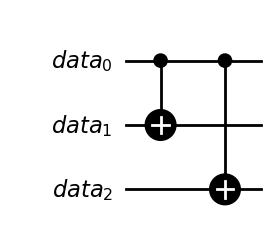


Encoding circuit for logical |1⟩:


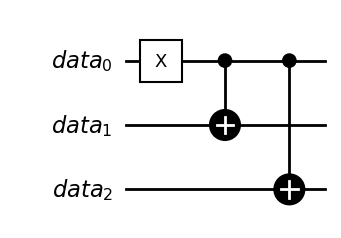


── Statevector verification ────────────────────────────────────────
  |0⟩ encoded → non-zero amplitudes:
    |000⟩  amplitude = 1.0000+0.0000j

  |1⟩ encoded → non-zero amplitudes:
    |111⟩  amplitude = 1.0000+0.0000j

✅ Encoding verified: |0⟩ → |000⟩  and  |1⟩ → |111⟩


In [ ]:
def build_encoding_circuit(logical_state=0):

    data = QuantumRegister(3, 'data')
    qc   = QuantumCircuit(data)

    # Step 1: prepare logical state
    if logical_state == 1:
        qc.x(data[0])          # flip qubit 0 to |1⟩

    # Step 2: encode by copying qubit 0 to qubits 1 and 2
    qc.cx(data[0], data[1])    # CNOT: data[0] → data[1]
    qc.cx(data[0], data[2])    # CNOT: data[0] → data[2]

    return qc


# ── Visualise the encoding circuit ──────────────────────────────────────────
print('Encoding circuit for logical |0⟩:')
qc_enc_0 = build_encoding_circuit(logical_state=0)
display(qc_enc_0.draw('mpl', style='bw', fold=-1))

print('\nEncoding circuit for logical |1⟩:')
qc_enc_1 = build_encoding_circuit(logical_state=1)
display(qc_enc_1.draw('mpl', style='bw', fold=-1))

# ── Verify the encoded states ────────────────────────────────────────────────
print('\n── Statevector verification ────────────────────────────────────────')
sv0 = Statevector(qc_enc_0)
sv1 = Statevector(qc_enc_1)

print(f'  |0⟩ encoded → non-zero amplitudes:')
for i, amp in enumerate(sv0.data):
    if abs(amp) > 1e-9:
        print(f'    |{i:03b}⟩  amplitude = {amp:.4f}')

print(f'\n  |1⟩ encoded → non-zero amplitudes:')
for i, amp in enumerate(sv1.data):
    if abs(amp) > 1e-9:
        print(f'    |{i:03b}⟩  amplitude = {amp:.4f}')

print('\n✅ Encoding verified: |0⟩ → |000⟩  and  |1⟩ → |111⟩')

Error Injection


State after encoding + error injection (logical |0⟩):
───────────────────────────────────────────────────────
  No error injected               →  dominant state: |000⟩
  X error on qubit 0              →  dominant state: |001⟩
  X error on qubit 1              →  dominant state: |010⟩
  X error on qubit 2              →  dominant state: |100⟩




,Scenario,Dominant state,Probability
0,No error injected,|000⟩,1.0000
1,X error on qubit 0,|001⟩,1.0000
2,X error on qubit 1,|010⟩,1.0000
3,X error on qubit 2,|100⟩,1.0000



Circuit diagram — error on qubit 1:


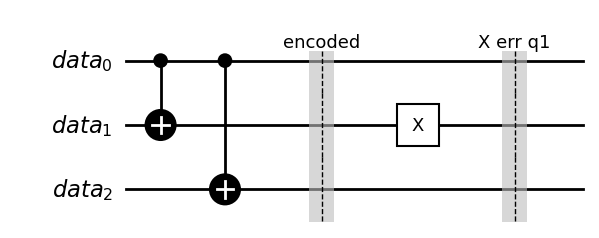

In [ ]:
def build_encoded_with_error(logical_state=0, error_qubit=None):

    data = QuantumRegister(3, 'data')
    qc   = QuantumCircuit(data)

    # ENCODING
    if logical_state == 1:
        qc.x(data[0])
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])
    qc.barrier(label='encoded')

    # ERROR INJECTION
    if error_qubit is not None:
        qc.x(data[error_qubit])        # inject X (bit-flip) error
        qc.barrier(label=f'X err q{error_qubit}')

    return qc


# ── Show all error scenarios ─────────────────────────────────────────────────
scenarios = [
    (None,  'No error injected'),
    (0,     'X error on qubit 0'),
    (1,     'X error on qubit 1'),
    (2,     'X error on qubit 2'),
]

print('State after encoding + error injection (logical |0⟩):'
      '\n' + '─'*55)

results = []
for err_q, label in scenarios:
    qc = build_encoded_with_error(logical_state=0, error_qubit=err_q)
    sv = Statevector(qc)

    # find dominant state
    probs   = sv.probabilities_dict()
    dom     = max(probs, key=probs.get)
    results.append({'Scenario': label, 'Dominant state': f'|{dom}⟩', 'Probability': f'{probs[dom]:.4f}'})
    print(f'  {label:30s}  →  dominant state: |{dom}⟩')

df_scenarios = pd.DataFrame(results)
print('\n')
display(df_scenarios.style.set_caption('Error Injection Scenarios — Logical |0⟩').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]
))

# ── Draw circuit with error on qubit 1 ──────────────────────────────────────
print('\nCircuit diagram — error on qubit 1:')
display(build_encoded_with_error(logical_state=0, error_qubit=1).draw('mpl', style='bw', fold=-1))

Syndrome Extraction



Syndrome extraction results (logical |0⟩):
────────────────────────────────────────────────────────────
  No error injected             →  syndrome = 00  (decimal: 0)
  X error on qubit 0            →  syndrome = 01  (decimal: 1)
  X error on qubit 1            →  syndrome = 11  (decimal: 3)
  X error on qubit 2            →  syndrome = 10  (decimal: 2)



,Error scenario,Error qubit,"Syndrome [s1,s0]",Syndrome decimal
0,No error injected,None,00,0
1,X error on qubit 0,0,01,1
2,X error on qubit 1,1,11,3
3,X error on qubit 2,2,10,2



Syndrome extraction circuit (error on qubit 1):


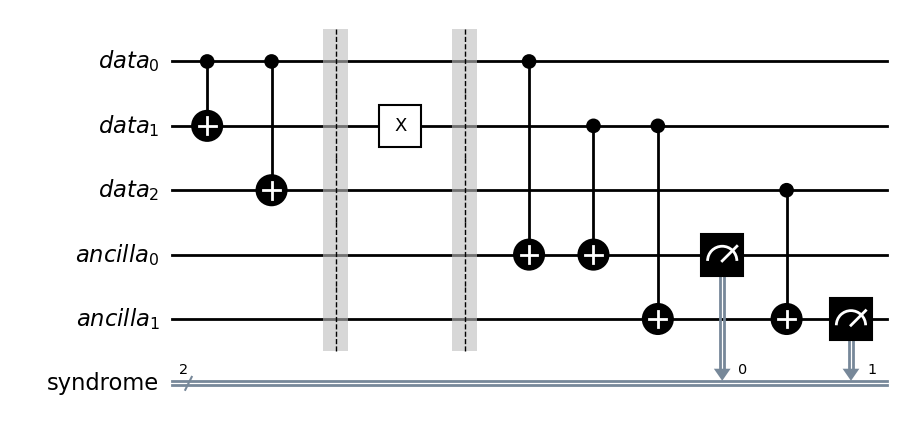

In [ ]:
def build_syndrome_circuit(logical_state=0, error_qubit=None):

    data          = QuantumRegister(3, 'data')
    ancilla       = QuantumRegister(2, 'ancilla')
    syndrome_bits = ClassicalRegister(2, 'syndrome')

    qc = QuantumCircuit(data, ancilla, syndrome_bits)

    # ── ENCODING ────────────────────────────────────────────────────────────
    if logical_state == 1:
        qc.x(data[0])
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])
    qc.barrier()

    # ── ERROR INJECTION ──────────────────────────────────────────────────────
    if error_qubit is not None:
        qc.x(data[error_qubit])
    qc.barrier()

    # ── SYNDROME EXTRACTION ──────────────────────────────────────────────────
    # ancilla[0] = parity of data[0] and data[1]
    qc.cx(data[0], ancilla[0])
    qc.cx(data[1], ancilla[0])

    # ancilla[1] = parity of data[1] and data[2]
    qc.cx(data[1], ancilla[1])
    qc.cx(data[2], ancilla[1])

    # ── MEASURE ANCILLA ONLY ─────────────────────────────────────────────────
    qc.measure(ancilla[0], syndrome_bits[0])
    qc.measure(ancilla[1], syndrome_bits[1])

    return qc, syndrome_bits


# ── Run syndrome extraction for all scenarios ────────────────────────────────
print('Syndrome extraction results (logical |0⟩):')
print('─' * 60)

SHOTS = 1024
syndrome_results = []

for err_q, label in scenarios:
    qc, _ = build_syndrome_circuit(logical_state=0, error_qubit=err_q)
    counts = simulator.run(qc, shots=SHOTS).result().get_counts()

    # Most common syndrome
    dominant_syndrome = max(counts, key=counts.get)
    syndrome_int      = int(dominant_syndrome, 2)

    print(f'  {label:28s}  →  syndrome = {dominant_syndrome}  (decimal: {syndrome_int})')
    syndrome_results.append({
        'Error scenario'   : label,
        'Error qubit'      : str(err_q),
        'Syndrome [s1,s0]' : dominant_syndrome,
        'Syndrome decimal' : syndrome_int
    })

print()
display(pd.DataFrame(syndrome_results).style.set_caption(
    'Syndrome Values for Each Error Scenario'
).set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]
))

# ── Draw syndrome circuit ────────────────────────────────────────────────────
print('\nSyndrome extraction circuit (error on qubit 1):')
qc_syn, _ = build_syndrome_circuit(logical_state=0, error_qubit=1)
display(qc_syn.draw('mpl', style='bw', fold=-1))

Syndrome-to-Error Mapping Table


In [ ]:
# ── Syndrome-to-error mapping (hardcoded from theory) ───────────────────────
# Syndrome bits are read in little-endian order from Qiskit
# syndrome_bits[0] = LSB = s0,  syndrome_bits[1] = MSB = s1

SYNDROME_TABLE = {
    #  int  binary  s1  s0   error location   correction
    0: {'binary': '00', 's1': 0, 's0': 0, 'error': 'No error',   'correction': 'None',         'qubit': -1},
    1: {'binary': '01', 's1': 0, 's0': 1, 'error': 'X on q0',    'correction': 'X on qubit 0', 'qubit': 0},
    3: {'binary': '11', 's1': 1, 's0': 1, 'error': 'X on q1',    'correction': 'X on qubit 1', 'qubit': 1},
    2: {'binary': '10', 's1': 1, 's0': 0, 'error': 'X on q2',    'correction': 'X on qubit 2', 'qubit': 2},
}

# ── How the syndrome is derived from parity checks ───────────────────────────
print('How Syndromes Are Derived:')
print('─' * 70)
print('  ancilla[0] (s0) = data[0] XOR data[1]')
print('  ancilla[1] (s1) = data[1] XOR data[2]')
print()
print('  No error:   data = 000  →  s0 = 0⊕0 = 0,  s1 = 0⊕0 = 0  →  syndrome 00')
print('  Error q0:   data = 100  →  s0 = 1⊕0 = 1,  s1 = 0⊕0 = 0  →  syndrome 01')
print('  Error q1:   data = 010  →  s0 = 0⊕1 = 1,  s1 = 1⊕0 = 1  →  syndrome 11')
print('  Error q2:   data = 001  →  s0 = 0⊕0 = 0,  s1 = 0⊕1 = 1  →  syndrome 10')
print()

# ── Display the full mapping table ───────────────────────────────────────────
table_rows = []
for syn_int in [0, 1, 3, 2]:   # order: 00, 01, 11, 10
    row = SYNDROME_TABLE[syn_int]
    table_rows.append({
        'Syndrome [s1 s0]'  : row['binary'],
        'Decimal'           : syn_int,
        's1 (ancilla[1])'   : row['s1'],
        's0 (ancilla[0])'   : row['s0'],
        'Error Location'    : row['error'],
        'Correction Gate'   : row['correction'],
        'Qubit Index'       : row['qubit'] if row['qubit'] >= 0 else '—',
    })

df_table = pd.DataFrame(table_rows)

# Style the table
def color_rows(row):
    if row['Error Location'] == 'No error':
        return ['background-color: #e8f5e9'] * len(row)
    else:
        return ['background-color: #fff3e0'] * len(row)

styled = df_table.style\
    .apply(color_rows, axis=1)\
    .set_caption('📋 Syndrome-to-Error Mapping Table — 3-Qubit Repetition Code')\
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-weight', 'bold'), ('font-size', '16px'), ('padding-bottom', '10px')]},
        {'selector': 'th',
         'props': [('background-color', '#263238'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '8px 16px')]},
    ])

display(styled)

# ── Decoder function ─────────────────────────────────────────────────────────
def decode_syndrome(syndrome_int):
    """
    Decode a 2-bit syndrome integer and return the qubit to correct.

    Parameters
    ----------
    syndrome_int : int  (0, 1, 2, or 3)

    Returns
    -------
    qubit_to_correct : int  (-1 means no correction needed)
    """
    return SYNDROME_TABLE.get(syndrome_int, {'qubit': -1})['qubit']


print('\n✅ Decoder function ready')
print('   decode_syndrome(0) =', decode_syndrome(0), '  (no error)')
print('   decode_syndrome(1) =', decode_syndrome(1), '   (error on qubit 0)')
print('   decode_syndrome(3) =', decode_syndrome(3), '   (error on qubit 1)')
print('   decode_syndrome(2) =', decode_syndrome(2), '   (error on qubit 2)')

How Syndromes Are Derived:
──────────────────────────────────────────────────────────────────────
  ancilla[0] (s0) = data[0] XOR data[1]
  ancilla[1] (s1) = data[1] XOR data[2]

  No error:   data = 000  →  s0 = 0⊕0 = 0,  s1 = 0⊕0 = 0  →  syndrome 00
  Error q0:   data = 100  →  s0 = 1⊕0 = 1,  s1 = 0⊕0 = 0  →  syndrome 01
  Error q1:   data = 010  →  s0 = 0⊕1 = 1,  s1 = 1⊕0 = 1  →  syndrome 11
  Error q2:   data = 001  →  s0 = 0⊕0 = 0,  s1 = 0⊕1 = 1  →  syndrome 10



,Syndrome [s1 s0],Decimal,s1 (ancilla[1]),s0 (ancilla[0]),Error Location,Correction Gate,Qubit Index
0,00,0,0,0,No error,None,—
1,01,1,0,1,X on q0,X on qubit 0,0
2,11,3,1,1,X on q1,X on qubit 1,1
3,10,2,1,0,X on q2,X on qubit 2,2



✅ Decoder function ready
   decode_syndrome(0) = -1   (no error)
   decode_syndrome(1) = 0    (error on qubit 0)
   decode_syndrome(3) = 1    (error on qubit 1)
   decode_syndrome(2) = 2    (error on qubit 2)


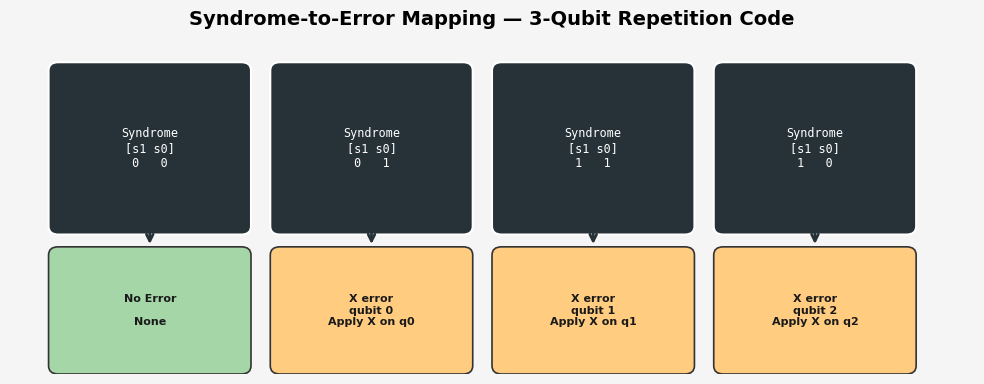

✅ Syndrome map saved as syndrome_map.png


In [ ]:
# ── Visual syndrome map ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')
ax.set_facecolor('#f5f5f5')
fig.patch.set_facecolor('#f5f5f5')

ax.set_title('Syndrome-to-Error Mapping — 3-Qubit Repetition Code',
             fontsize=14, fontweight='bold', pad=15)

entries = [
    (1.5,  'Syndrome\n[s1 s0]\n 0   0 ', 'No Error\n\nNone', '#a5d6a7'),
    (3.8,  'Syndrome\n[s1 s0]\n 0   1 ', 'X error\nqubit 0\nApply X on q0', '#ffcc80'),
    (6.1,  'Syndrome\n[s1 s0]\n 1   1 ', 'X error\nqubit 1\nApply X on q1', '#ffcc80'),
    (8.4,  'Syndrome\n[s1 s0]\n 1   0 ', 'X error\nqubit 2\nApply X on q2', '#ffcc80'),
]

for x, syn_text, err_text, color in entries:
    # syndrome box
    rect = mpatches.FancyBboxPatch((x-1.0, 1.8), 1.9, 1.9,
                                    boxstyle='round,pad=0.1',
                                    facecolor='#263238', edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x-0.05, 2.75, syn_text, ha='center', va='center',
            fontsize=8.5, color='white', fontfamily='monospace')

    # arrow
    ax.annotate('', xy=(x-0.05, 1.55), xytext=(x-0.05, 1.8),
                arrowprops=dict(arrowstyle='->', color='#263238', lw=2))

    # correction box
    rect2 = mpatches.FancyBboxPatch((x-1.0, 0.1), 1.9, 1.35,
                                     boxstyle='round,pad=0.1',
                                     facecolor=color, edgecolor='#333', linewidth=1.2)
    ax.add_patch(rect2)
    ax.text(x-0.05, 0.77, err_text, ha='center', va='center',
            fontsize=8, color='#1a1a1a', fontweight='bold')

plt.tight_layout()
plt.savefig('syndrome_map.png', dpi=150, bbox_inches='tight', facecolor='#f5f5f5')
plt.show()
print('✅ Syndrome map saved as syndrome_map.png')

Correction & Decoding



Full Correction Pipeline Results (logical |0⟩):
──────────────────────────────────────────────────────────────────────
  No error injected             syndrome=00  success=100.0%  ✅ Corrected
  X error on qubit 0            syndrome=01  success=100.0%  ✅ Corrected
  X error on qubit 1            syndrome=11  success=100.0%  ✅ Corrected
  X error on qubit 2            syndrome=10  success=100.0%  ✅ Corrected



,Scenario,Syndrome,Corrected?,Success Rate,Final Counts
0,No error injected,00,— No error,100.0%,{'0': 1024}
1,X error on qubit 0,01,✅ Yes,100.0%,{'0': 1024}
2,X error on qubit 1,11,✅ Yes,100.0%,{'0': 1024}
3,X error on qubit 2,10,✅ Yes,100.0%,{'0': 1024}



Full pipeline circuit (error on qubit 1, then corrected):


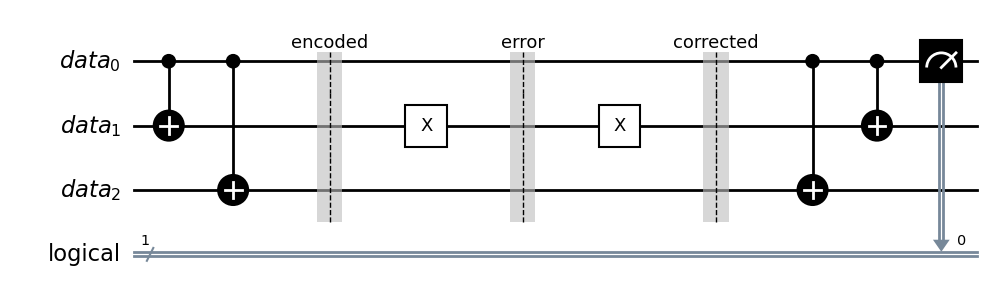

In [ ]:
def build_full_repetition_circuit(logical_state=0, error_qubit=None):
    """
    Full repetition code pipeline:
        Encoding → Error Injection → Syndrome Extraction
        → Classical Decoding → Correction → Decoding → Measurement

    Correction is done classically in Python after reading the syndrome.
    This avoids dynamic circuit issues in Qiskit Aer.

    Returns
    -------
    final_counts  : dict   — measurement outcomes of the logical qubit
    syndrome_seen : str    — the syndrome that was measured
    corrected     : bool   — whether a correction was applied
    success_rate  : float  — fraction of shots that recovered correct logical state
    """
    SHOTS = 1024

    # ── STEP 1: Run syndrome extraction circuit ──────────────────────────────
    data          = QuantumRegister(3, 'data')
    ancilla       = QuantumRegister(2, 'ancilla')
    syndrome_bits = ClassicalRegister(2, 'syndrome')

    qc_syn = QuantumCircuit(data, ancilla, syndrome_bits)

    if logical_state == 1:
        qc_syn.x(data[0])
    qc_syn.cx(data[0], data[1])
    qc_syn.cx(data[0], data[2])
    qc_syn.barrier()

    if error_qubit is not None:
        qc_syn.x(data[error_qubit])
    qc_syn.barrier()

    qc_syn.cx(data[0], ancilla[0])
    qc_syn.cx(data[1], ancilla[0])
    qc_syn.cx(data[1], ancilla[1])
    qc_syn.cx(data[2], ancilla[1])
    qc_syn.measure(ancilla[0], syndrome_bits[0])
    qc_syn.measure(ancilla[1], syndrome_bits[1])

    syn_counts = simulator.run(qc_syn, shots=SHOTS).result().get_counts()
    syndrome_seen = max(syn_counts, key=syn_counts.get)
    syndrome_int  = int(syndrome_seen, 2)
    qubit_to_fix  = decode_syndrome(syndrome_int)

    # ── STEP 2: Apply correction + decode + measure ──────────────────────────
    logical_bit = ClassicalRegister(1, 'logical')
    qc_corr     = QuantumCircuit(data, logical_bit)

    if logical_state == 1:
        qc_corr.x(data[0])
    qc_corr.cx(data[0], data[1])
    qc_corr.cx(data[0], data[2])
    qc_corr.barrier(label='encoded')

    if error_qubit is not None:
        qc_corr.x(data[error_qubit])
    qc_corr.barrier(label='error')

    # Apply correction
    corrected = False
    if qubit_to_fix >= 0:
        qc_corr.x(data[qubit_to_fix])
        corrected = True
    qc_corr.barrier(label='corrected')

    # Decode: reverse the encoding
    qc_corr.cx(data[0], data[2])
    qc_corr.cx(data[0], data[1])
    qc_corr.measure(data[0], logical_bit[0])

    final_counts = simulator.run(qc_corr, shots=SHOTS).result().get_counts()
    correct_key  = str(logical_state)
    success_rate = final_counts.get(correct_key, 0) / SHOTS

    return final_counts, syndrome_seen, corrected, success_rate, qc_corr


# ── Run all scenarios ────────────────────────────────────────────────────────
print('Full Correction Pipeline Results (logical |0⟩):')
print('─' * 70)

correction_results = []
for err_q, label in scenarios:
    counts, syndrome, corrected, success, qc_full = build_full_repetition_circuit(
        logical_state=0, error_qubit=err_q
    )
    status = '✅ Corrected' if (err_q is None or corrected) else '❌ Failed'
    print(f'  {label:28s}  syndrome={syndrome}  success={success:.1%}  {status}')
    correction_results.append({
        'Scenario'       : label,
        'Syndrome'       : syndrome,
        'Corrected?'     : '✅ Yes' if corrected else '— No error',
        'Success Rate'   : f'{success:.1%}',
        'Final Counts'   : str(counts)
    })

print()
display(pd.DataFrame(correction_results).style.set_caption(
    'Correction Pipeline — Results Summary'
).set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]},
     {'selector': 'th', 'props': [('background-color', '#263238'), ('color', 'white')]}]
))

# ── Draw the full circuit ────────────────────────────────────────────────────
print('\nFull pipeline circuit (error on qubit 1, then corrected):')
_, _, _, _, qc_full = build_full_repetition_circuit(logical_state=0, error_qubit=1)
display(qc_full.draw('mpl', style='bw', fold=-1))